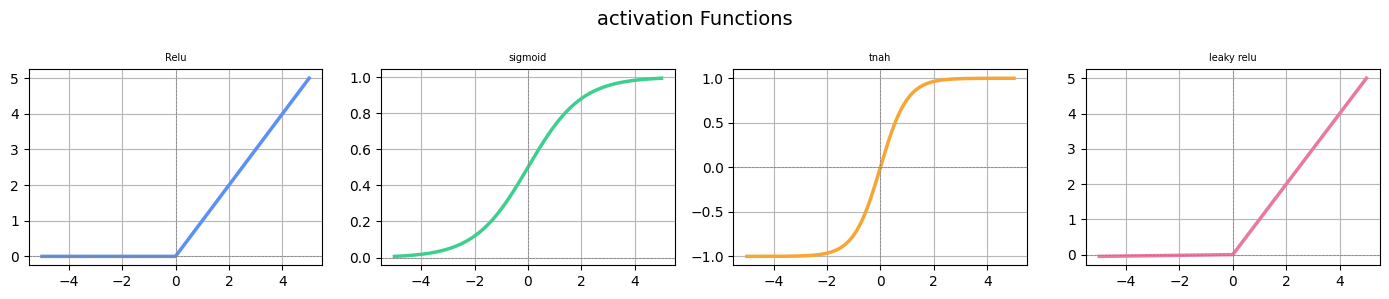

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
x=np.linspace(-5,5,300)

relu=lambda x:np.maximum(0,x)
sigmoid=lambda x:1/(1+np.exp(-x))
tanh_fn=np.tanh
leaky=lambda x:np.where(x>0,x,0.01*x)

fig,axes=plt.subplots(1,4,figsize=(14,3))
fns=[relu,sigmoid,tanh_fn,leaky]
names=['Relu','sigmoid','tnah','leaky relu']
cols=['#5B8FF9','#3ECF8E','#F5A634','#E879A0']

for ax,fn,name,color in zip(axes,fns,names,cols):
    ax.plot(x,fn(x),color=color,linewidth=2.5)
    ax.axhline(0,color='gray',lw=0.5,ls='--')
    ax.axvline(0,color='gray',lw=0.5,ls='--')
    ax.set_title(name,fontsize=7)
    ax.grid(alpha=0.9)
plt.suptitle('activation Functions',fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

(x_train,y_train),(x_test,y_test)=keras.datasets.mnist.load_data()
x_train=x_train.reshape(-1,784)
x_test=x_test.reshape(-1,784)

x_train=x_train.astype('float32')/255.0
x_test=x_test.astype('float32')/255.
print(f'Train:{x_train.shape},{x_test.shape}')

model=keras.Sequential([keras.Input(shape=(784,)),
layers.Dense(128,activation='relu'),
layers.Dropout(0.2),

layers.Dense(64,activation='relu'),
layers.Dropout(0.2),

layers.Dense(10,activation='softmax'),
])

model.summary()



Train:(60000, 784),(10000, 784)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9902 - loss: 0.0315 - val_accuracy: 0.9838 - val_loss: 0.0673 - learning_rate: 0.0010
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9895 - loss: 0.0328 - val_accuracy: 0.9842 - val_loss: 0.0684 - learning_rate: 0.0010
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9901 - loss: 0.0297 - val_accuracy: 0.9853 - val_loss: 0.0662 - learning_rate: 0.0010
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9908 - loss: 0.0263 - val_accuracy: 0.9838 - val_loss: 0.0639 - learning_rate: 0.0010
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9908 - loss: 0.0276 - val_accuracy: 0.9833 - val_loss: 0.0773 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 3.
Test Accuracy: 98.20%
Test Loss: 0.0800


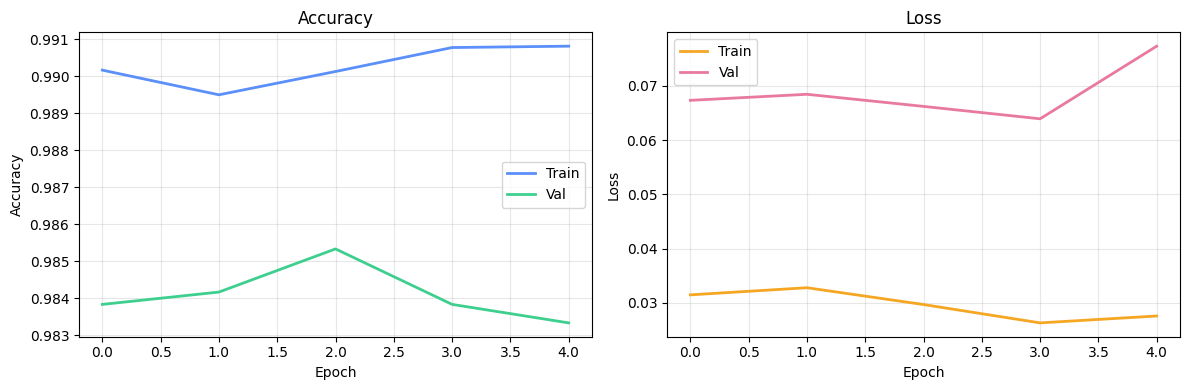

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau

early_stopping=EarlyStopping(monitor='val_accuracy',patience=5,restore_best_weights=True,verbose=1)
reduce_lr=ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=3,min_lr=1e-6,verbose=1)
history=model.fit(x_train,y_train,
                  epochs=5,
                  batch_size=128,
                  validation_split=0.1,
                  callbacks=[early_stopping,reduce_lr],
                  verbose=1
                  )
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f'Test Accuracy: {test_acc*100:.2f}%')
print(f'Test Loss: {test_loss:.4f}')
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['accuracy'], label='Train', color='#5B8FF9', lw=2)
ax1.plot(history.history['val_accuracy'], label='Val', color='#3ECF8E', lw=2)
ax1.set(title='Accuracy', xlabel='Epoch', ylabel='Accuracy')
ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(history.history['loss'], label='Train', color='#F5A623', lw=2)
ax2.plot(history.history['val_loss'], label='Val', color='#E879A0', lw=2)
ax2.set(title='Loss', xlabel='Epoch', ylabel='Loss')
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report
# ■■ Load and preprocess MNIST ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()
X_train = X_train.reshape(-1, 784).astype('float32') / 255.0
X_test = X_test.reshape(-1, 784).astype('float32') / 255.0
# ■■ Visualise a sample of training digits ■■■■■■■■■■■■■■■■■■■■■
fig, axes = plt.subplots(2, 10, figsize=(14, 3))
for d in range(10):
  for r, offset in enumerate([0, 1]):
    idx = np.where(y_train == d)[0][offset]
    axes[r, d].imshow(X_train[idx].reshape(28,28), cmap='gray')
    axes[r, d].set_title(str(d), fontsize=8); axes[r, d].axis('off')
plt.suptitle('MNIST: 2 samples per digit'); plt.tight_layout(); plt.show()
# ■■ Build model as a reusable function ■■■■■■■■■■■■■■■■■■■■■■■
def make_model(h1=256, h2=128, drop=0.3):
  m = keras.Sequential([
  keras.Input(shape=(784,)),
  layers.Dense(h1, activation='relu'),
  layers.Dropout(drop),
  layers.Dense(h2, activation='relu'),
                       layers.Dropout(drop),
  layers.Dense(10, activation='softmax'),
  ])
  m.compile(optimizer='adam',
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy'])
  return m
model = make_model()
model.summary()

In [ ]:
# ■■ Train ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
history = model.fit(
X_train, y_train, epochs=30, batch_size=128,
validation_split=0.1,
callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
verbose=1)
# ■■ Evaluate ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Accuracy: {acc*100:.2f}%')
# ■■ Confusion matrix ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
y_pred = np.argmax(model.predict(X_test), axis=1)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
xticklabels=range(10), yticklabels=range(10))
plt.title(f'Confusion Matrix — Test Accuracy {acc*100:.1f}%')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout(); plt.show()
# Diagonal = correctly classified. Off-diagonal = confused pairs.
# Common confusions: 4 vs 9, 3 vs 8, 5 vs 6
print(classification_report(y_test, y_pred))
# ■■ Show misclassified images ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
wrong = np.where(y_pred != y_test)[0]
print(f'Misclassified: {len(wrong)} out of {len(y_test)}')
fig, axes = plt.subplots(3, 8, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
  if i < len(wrong):
    idx = wrong[i]
    ax.imshow(X_test[idx].reshape(28,28), cmap='gray')
    ax.set_title(f'T:{y_test[idx]} P:{y_pred[idx]}',
    color='red', fontsize=7)
  ax.axis('off')
plt.suptitle('Misclassified Digits (T=True, P=Predicted)')
plt.tight_layout(); plt.show()
# ■■ Architecture comparison ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
configs = [
(64, 32, 0.0, 'Small / no dropout'),
(128, 64, 0.2, 'Medium / light dropout'),
(256, 128, 0.3, 'Large / moderate dropout'),
]
for h1, h2, dr, label in configs:
  m = make_model(h1, h2, dr)
  m.fit(X_train, y_train, epochs=15, batch_size=128,
    validation_split=0.1, verbose=0,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)])
_, a = m.evaluate(X_test, y_test, verbose=0)
print(f'{label:35s} Accuracy: {a*100:.2f}%')

In [ ]:
# ■■ Each Layer 1 neuron has 784 weights (one per pixel) ■■■■■■■■
# Reshape to 28x28 to see which pixel patterns each neuron responds to
weights = model.layers[0].get_weights()[0] # shape: (784, 256)
fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
  w = weights[:, i].reshape(28, 28)
  ax.imshow(w, cmap='RdBu', vmin=-w.max(), vmax=w.max())
  ax.axis('off')
plt.suptitle('Layer 1 Neuron Weight Patterns — What Each Neuron Detects')
plt.tight_layout(); plt.show()
# Blue = neuron activated strongly by bright pixel here
# Red = neuron suppressed by bright pixel here